[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/06_power_delay_profile_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 📶 Power Delay Profile, Delay Spread & Coherence Bandwidth
### Interactive Teaching Notebook — DHBW Mobile Communications
---
This notebook makes the **time-domain / frequency-domain pair** of slide set 2 tangible:

| Time domain | Frequency domain |
|---|---|
| **Power Delay Profile** $P(\tau)$ | transfer function $\underline{H}(f)$ |
| **Delay spread** $\tau_{DS}$ | **correlation bandwidth** $B_{Korr,x\%}$ |

You will *see* that the PDP and the frequency-ACF really are a **Fourier pair**, and that
$\tau_{DS}\sim 1/B_{Korr}$ is not a slogan but arithmetic.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

### Power Delay Profile (PDP)
$N$ paths arrive with **excess delay** $\tau_i$ (the first path defines $\tau = 0$) and power
$P(\tau_i)$. Powers are usually given in dB and must be converted first:

$$P_{lin} = 10^{P_{dB}/10}$$

### Delay spread (the standard deviation of the PDP)

$$\bar{\tau}=\frac{\sum_i P(\tau_i)\,\tau_i}{\sum_i P(\tau_i)}
\qquad
\overline{\tau^{2}}=\frac{\sum_i P(\tau_i)\,\tau_i^{2}}{\sum_i P(\tau_i)}
\qquad
\tau_{DS}=\sqrt{\overline{\tau^{2}}-\bar{\tau}^{\,2}}$$

> Careful: $\overline{\tau^{2}}$ (mean of the squares) is **not** $\bar\tau^{2}$ (square of the mean).
> Their difference is the variance.

### Frequency ACF and correlation bandwidth
The frequency autocorrelation function is the **Fourier transform of the PDP**:

$$\rho(\Delta f)=\frac{\left|\sum_i P(\tau_i)\,e^{-j2\pi\Delta f\tau_i}\right|}{\sum_i P(\tau_i)}$$

$B_{Korr,x\%}$ is the smallest $\Delta f$ at which $|\rho(\Delta f)|$ falls below $x\%$
(the slide uses $x = 37\%$, i.e. $1/e$).

$$\boxed{\ \tau_{DS}\ \sim\ \frac{1}{B_{Korr,x\%}}\ }$$

### Why it matters
A symbol of duration $T_s$ suffers inter-symbol interference once $\tau_{DS}\gtrsim T_s$;
equivalently, a signal of bandwidth $B \gtrsim B_{Korr}$ sees a **frequency-selective** channel.

---

In [3]:
# ---------------------------------------------------------------
#  CORE FUNCTIONS
# ---------------------------------------------------------------
c0 = 3e8

def pdp_stats(tau_us, P_dB):
    """Delay spread of a discrete PDP.  tau in us, power in dB.
    Returns (tau_bar, tau2_bar, tau_DS) in us / us^2 / us."""
    tau = np.asarray(tau_us, dtype=float)
    P   = 10.0 ** (np.asarray(P_dB, dtype=float) / 10.0)   # dB -> linear
    Ps  = P.sum()
    tau_bar  = (P * tau).sum() / Ps
    tau2_bar = (P * tau**2).sum() / Ps
    tau_DS   = np.sqrt(max(tau2_bar - tau_bar**2, 0.0))
    return tau_bar, tau2_bar, tau_DS

def freq_acf(tau_us, P_dB, df_MHz):
    """|rho(df)| = |FT{PDP}| , normalised to rho(0)=1."""
    tau = np.asarray(tau_us, float) * 1e-6            # s
    P   = 10.0 ** (np.asarray(P_dB, float) / 10.0)
    df  = np.asarray(df_MHz, float) * 1e6             # Hz
    phase = np.exp(-2j * np.pi * np.outer(df, tau))
    return np.abs(phase @ P) / P.sum()

def correlation_bandwidth(tau_us, P_dB, level=0.37, df_max_MHz=20.0, n=8000):
    """First df where |rho| drops below `level`.  Returns MHz (or None)."""
    df = np.linspace(0, df_max_MHz, n)
    r  = freq_acf(tau_us, P_dB, df)
    below = np.where(r < level)[0]
    return (df[below[0]] if below.size else None), df, r

def transfer_function(tau_us, P_dB, f_MHz, seed=0):
    """|H(f)| for the given PDP with random (but fixed) tap phases."""
    """Computes the complex channel frequency response $H(f)$ using the discrete channel transfer function: $$H(f) = \sum_{k} a_k e^{j \phi_k} e^{-j 2 \pi f \tau_k}$$."""
    rng   = np.random.default_rng(seed)
    tau   = np.asarray(tau_us, float) * 1e-6
    a     = np.sqrt(10.0 ** (np.asarray(P_dB, float) / 10.0))
    phi   = rng.uniform(0, 2*np.pi, a.size)
    f     = np.asarray(f_MHz, float) * 1e6
    H     = (a * np.exp(1j*phi)) @ np.exp(-2j*np.pi*np.outer(tau, f))
    return np.abs(H)

print("Core functions defined.")

Core functions defined.


In [4]:
# ---------------------------------------------------------------
#  CHECK AGAINST THE LECTURE SLIDE
#  Slide "frequency selectivity in the time domain (3)":
#     0 dB @ 5 us,  -10 dB @ 1 us,  -10 dB @ 2 us,  -20 dB @ 0 us
#  Expected:  tau_bar = 4.38 us,  tau^2_bar = 21.07 us^2,  tau_DS = 1.37 us
# ---------------------------------------------------------------
tau_slide = [0.0, 1.0, 2.0, 5.0]
P_slide   = [-20.0, -10.0, -10.0, 0.0]

tb, t2b, tds = pdp_stats(tau_slide, P_slide)
print(f"  tau_bar   = {tb:6.3f} us      (slide: 4.38 us)")
print(f"  tau^2_bar = {t2b:6.3f} us^2   (slide: 21.07 us^2)")
print(f"  tau_DS    = {tds:6.3f} us      (slide: 1.37 us)")

# --- and now a caution the slide does not spell out -------------------
Bc, df, rho = correlation_bandwidth(tau_slide, P_slide, level=0.37, df_max_MHz=5.0)
print(f"\n  B_Korr,37%  = {Bc}   <-- there is none!")
print(f"  min |rho|   = {rho.min():.2f}")
print("""
  Why?  This PDP has ONE dominant path (0 dB) and three weak echoes.
  The frequency ACF therefore only ripples between about 0.65 and 1 and never
  reaches 0.37.  A correlation bandwidth only exists for the levels the curve
  actually crosses -- always quote B_Korr together with its percentage x%.
""")
Bc90, _, _ = correlation_bandwidth(tau_slide, P_slide, level=0.90, df_max_MHz=5.0)
print(f"  B_Korr,90%  = {Bc90*1000:.0f} kHz   (measured on this PDP)")
print(f"\n  Common engineering rules of thumb:")
print(f"    B_Korr,50% ~ 1/(5  * tau_DS) = {1/(5*tds*1e-6)/1e3:6.0f} kHz")
print(f"    B_Korr,90% ~ 1/(50 * tau_DS) = {1/(50*tds*1e-6)/1e3:6.0f} kHz")
print("  -> the same order of magnitude, which is all the slide claims with '~'.")

  tau_bar   =  4.380 us      (slide: 4.38 us)
  tau^2_bar = 21.074 us^2   (slide: 21.07 us^2)
  tau_DS    =  1.374 us      (slide: 1.37 us)

  B_Korr,37%  = None   <-- there is none!
  min |rho|   = 0.67

  Why?  This PDP has ONE dominant path (0 dB) and three weak echoes.
  The frequency ACF therefore only ripples between about 0.65 and 1 and never
  reaches 0.37.  A correlation bandwidth only exists for the levels the curve
  actually crosses -- always quote B_Korr together with its percentage x%.

  B_Korr,90%  = 54 kHz   (measured on this PDP)

  Common engineering rules of thumb:
    B_Korr,50% ~ 1/(5  * tau_DS) =    146 kHz
    B_Korr,90% ~ 1/(50 * tau_DS) =     15 kHz
  -> the same order of magnitude, which is all the slide claims with '~'.


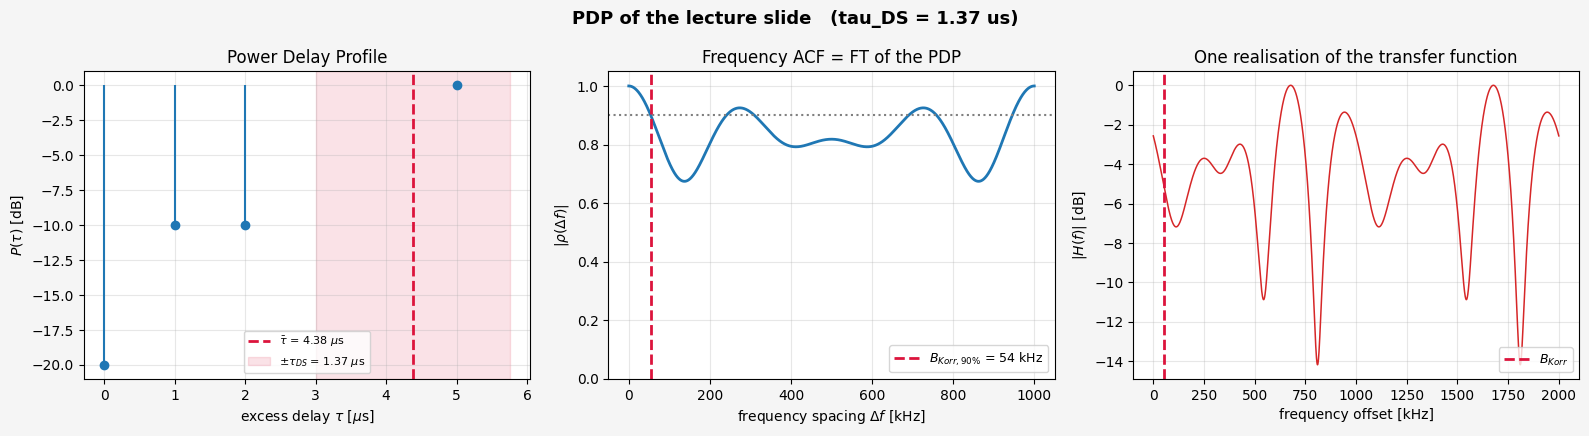

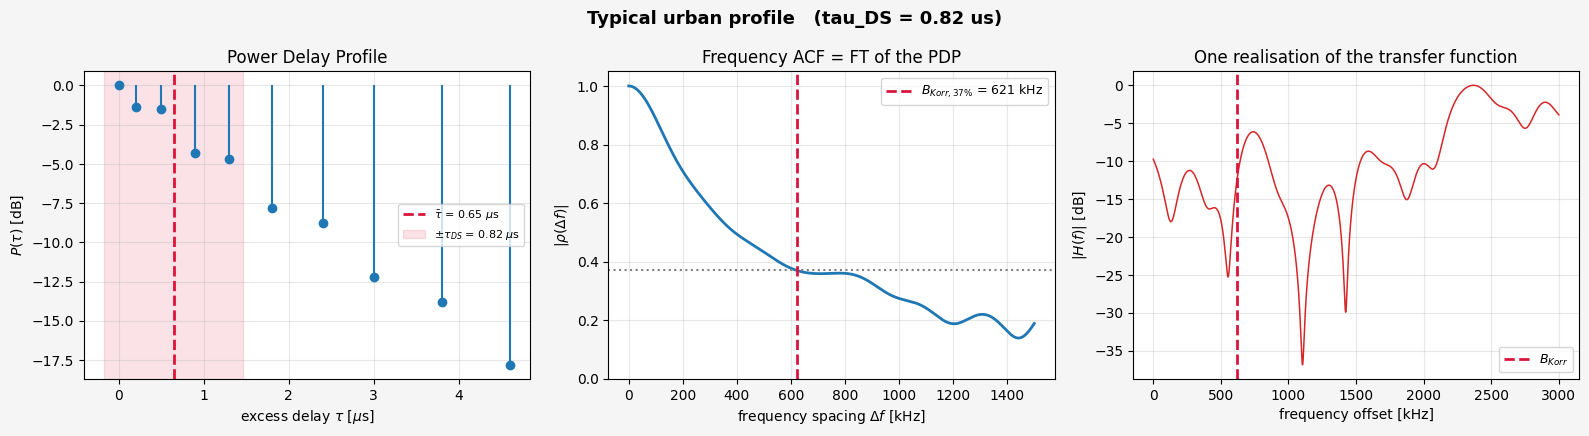

In [5]:
# ---------------------------------------------------------------
#  THE FOUR PICTURES SIDE BY SIDE (for the slide example)
# ---------------------------------------------------------------
def plot_pdp_scene(tau_us, P_dB, level=0.37, df_max_MHz=2.0, title=""):
    tb, t2b, tds = pdp_stats(tau_us, P_dB)
    Bc, df, rho  = correlation_bandwidth(tau_us, P_dB, level, df_max_MHz)

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

    # --- 1) the PDP itself -------------------------------------------------
    ax[0].stem(tau_us, P_dB, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    ax[0].axvline(tb, color="crimson", ls="--", lw=2,
                  label=fr"$\bar\tau$ = {tb:.2f} $\mu$s")
    ax[0].axvspan(tb-tds, tb+tds, color="crimson", alpha=0.12,
                  label=fr"$\pm\tau_{{DS}}$ = {tds:.2f} $\mu$s")
    ax[0].set_xlabel(r"excess delay $\tau$ [$\mu$s]")
    ax[0].set_ylabel(r"$P(\tau)$ [dB]")
    ax[0].set_title("Power Delay Profile")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

    # --- 2) frequency ACF --------------------------------------------------
    ax[1].plot(df*1000, rho, color="C0", lw=2)
    ax[1].axhline(level, color="gray", ls=":", lw=1.5)
    if Bc is not None:
        ax[1].axvline(Bc*1000, color="crimson", ls="--", lw=2,
                      label=fr"$B_{{Korr,{int(level*100)}\%}}$ = {Bc*1000:.0f} kHz")
    else:
        ax[1].plot([], [], ' ',
                   label=f"never reaches {level:.2f}\n(min = {rho.min():.2f})")
    ax[1].legend(fontsize=9)
    ax[1].set_xlabel(r"frequency spacing $\Delta f$ [kHz]")
    ax[1].set_ylabel(r"$|\rho(\Delta f)|$")
    ax[1].set_title("Frequency ACF = FT of the PDP")
    ax[1].set_ylim(0, 1.05); ax[1].grid(alpha=.3)

    # --- 3) one realisation of |H(f)| --------------------------------------
    fsw = np.linspace(0, df_max_MHz*2, 4000)
    H   = transfer_function(tau_us, P_dB, fsw)
    HdB = 20*np.log10(np.maximum(H, 1e-6) / np.max(H))
    ax[2].plot(fsw*1000, HdB, color="C3", lw=1.1)
    if Bc is not None and Bc < fsw[-1]:
        ax[2].axvline(Bc*1000, color="crimson", ls="--", lw=2,
                      label=r"$B_{Korr}$")
        ax[2].legend(fontsize=9, loc="lower right")
    ax[2].set_xlabel("frequency offset [kHz]")
    ax[2].set_ylabel(r"$|H(f)|$ [dB]")
    ax[2].set_title("One realisation of the transfer function")
    ax[2].grid(alpha=.3)

    fig.suptitle(title or "Frequency selectivity: time domain <-> frequency domain",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_pdp_scene(tau_slide, P_slide, level=0.90, df_max_MHz=1.0,
               title="PDP of the lecture slide   (tau_DS = 1.37 us)")

# A second, more typical urban profile: many echoes, exponentially decaying.
tau_urban = np.array([0.0, 0.2, 0.5, 0.9, 1.3, 1.8, 2.4, 3.0, 3.8, 4.6])
P_urban   = -3.0 * tau_urban - np.array([0,1,0,2,1,3,2,4,3,5])*0.8
_, _, tds_u = pdp_stats(tau_urban, P_urban)
plot_pdp_scene(tau_urban, P_urban, level=0.37, df_max_MHz=1.5,
               title=f"Typical urban profile   (tau_DS = {tds_u:.2f} us)")

In [6]:
# ---------------------------------------------------------------
#  INTERACTIVE: build your own PDP
# ---------------------------------------------------------------
style  = {'description_width': '190px'}
layout = widgets.Layout(width='520px')

sl_n     = widgets.IntSlider(value=4, min=2, max=12, step=1,
              description='number of paths N:', style=style, layout=layout)
sl_span  = widgets.FloatSlider(value=5.0, min=0.2, max=20.0, step=0.2,
              description='max excess delay [us]:', style=style, layout=layout)
sl_decay = widgets.FloatSlider(value=0.0, min=-20.0, max=10.0, step=0.5,
              description='power decay [dB per us]:', style=style, layout=layout)
sl_level = widgets.FloatSlider(value=0.37, min=0.1, max=0.9, step=0.01,
              description='correlation level x:', style=style, layout=layout)
sl_seed  = widgets.IntSlider(value=1, min=0, max=50, step=1,
              description='random layout (seed):', style=style, layout=layout)

def update(N, span, decay, level, seed):
    rng = np.random.default_rng(seed)
    tau = np.sort(np.concatenate([[0.0], rng.uniform(0, span, N-1)]))
    P   = decay * tau + rng.uniform(-4, 0, N)      # dB
    P   = P - P.max()                              # normalise strongest to 0 dB
    tb, t2b, tds = pdp_stats(tau, P)
    dfmax = max(0.5, 3.0 / max(tds, 1e-3))         # MHz, auto zoom
    plot_pdp_scene(tau, P, level=level, df_max_MHz=dfmax,
                   title=f"tau_DS = {tds:.2f} us")
    Bc, _, r = correlation_bandwidth(tau, P, level, dfmax)
    if Bc:
        print(f"tau_DS = {tds:.3f} us      B_Korr,{int(level*100)}% = {Bc*1000:.0f} kHz"
              f"      product tau_DS x B_Korr = {tds*1e-6*Bc*1e6:.2f}")
    else:
        print(f"tau_DS = {tds:.3f} us      |rho| never falls below {level:.2f} "
              f"(min = {r.min():.2f}) -> no B_Korr at this level")

ui  = widgets.VBox([sl_n, sl_span, sl_decay, sl_level, sl_seed])
out = widgets.interactive_output(update, {'N': sl_n, 'span': sl_span,
        'decay': sl_decay, 'level': sl_level, 'seed': sl_seed})
display(ui, out)

Output()

## 📝 Try this

1. **Reproduce the slide.** The check cell above must print 4.38 µs / 21.07 µs² / 1.37 µs.
   If you can get those three numbers by hand, you can do this in the exam.
2. **Stretch the profile.** Increase *max excess delay* and watch two things happen at once:
   $\tau_{DS}$ grows **and** $B_{Korr}$ shrinks. Note the product $\tau_{DS}\cdot B_{Korr}$
   printed under the plot — it stays roughly constant. That is
   *"frequency $\times$ bandwidth product = const"* from the slide.
3. **Kill the long paths.** Set *power decay* to $-15$ dB/µs so distant echoes are weak.
   The delay spread collapses and the transfer function becomes flat — a
   **non-selective** channel, even though there are still many paths.
4. **Change the level $x$.** $B_{Korr,90\%}$ is much narrower than $B_{Korr,37\%}$.
   The correlation bandwidth is only meaningful together with its percentage.

## 📌 Summary

| Quantity | Domain | Large value means |
|---|---|---|
| $\tau_{DS}$ delay spread | time | echoes spread far in time → **strongly** frequency-selective |
| $B_{Korr,x\%}$ correlation bandwidth | frequency | channel stays similar over a wide band → **weakly** selective |

They are inverse to each other because the PDP and the frequency-ACF are a **Fourier pair**.

*Rule of thumb:* if your signal bandwidth $B \ll B_{Korr}$ the channel is **flat**;
if $B \gtrsim B_{Korr}$ it is **frequency-selective** and you need an equaliser or OFDM.